In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

url = "https://raw.githubusercontent.com/minhaj-313/Netflix-Movies-and-TV-Shows-Dashboard/main/netflix_titles.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
# Basic info
print("=== INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== STATISTICS ===")
print(df.describe(include='all'))

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

=== MISSING VALUES ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
liste

In [9]:
#Cleaning the data
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("✅ Data cleaned!")
print(df.isnull().sum())

✅ Data cleaned!
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64


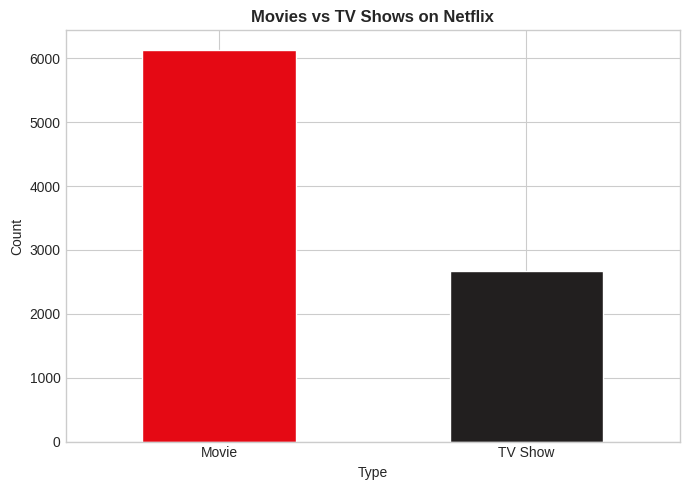

📊 movies_vs_shows.png saved!


In [10]:
#Movies VS Tv Shows
plt.figure(figsize=(7, 5))
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221F1F'], edgecolor='white')
plt.title('Movies vs TV Shows on Netflix', fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('movies_vs_shows.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 movies_vs_shows.png saved!")

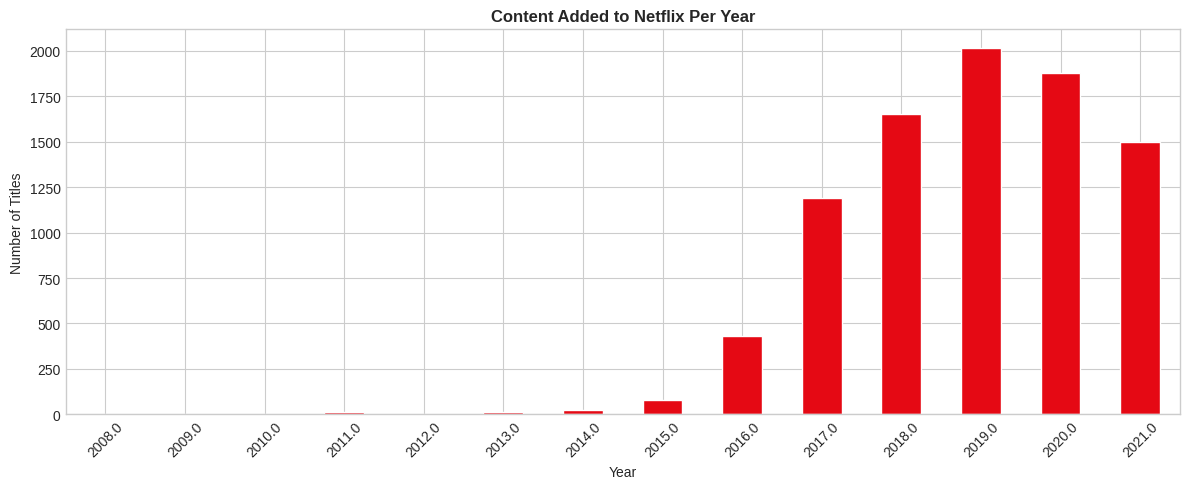

📊 content_per_year.png saved!


In [11]:
# Content Added Per Year (Trend)
plt.figure(figsize=(12, 5))
df['year_added'].value_counts().sort_index().plot(
    kind='bar', color='#E50914', edgecolor='white')
plt.title('Content Added to Netflix Per Year', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('content_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 content_per_year.png saved!")

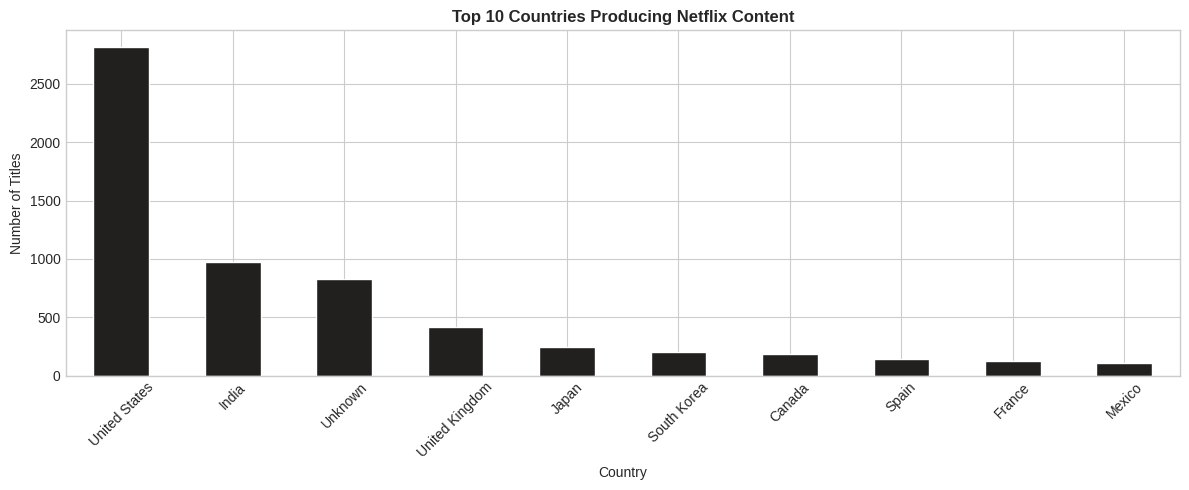

📊 top_countries.png saved!


In [12]:
# Top 10 Countries
plt.figure(figsize=(12, 5))
df['country'].value_counts().head(10).plot(
    kind='bar', color='#221F1F', edgecolor='white')
plt.title('Top 10 Countries Producing Netflix Content', fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 top_countries.png saved!")

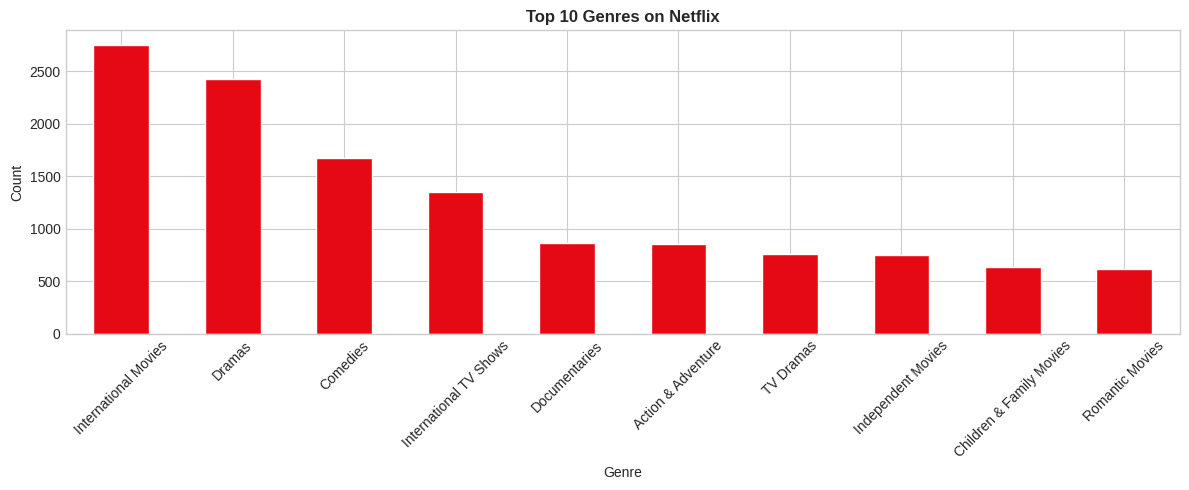

📊 top_genres.png saved!


In [13]:
#Top 10 Genres
genres = df['listed_in'].str.split(', ').explode()

plt.figure(figsize=(12, 5))
genres.value_counts().head(10).plot(
    kind='bar', color='#E50914', edgecolor='white')
plt.title('Top 10 Genres on Netflix', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 top_genres.png saved!")

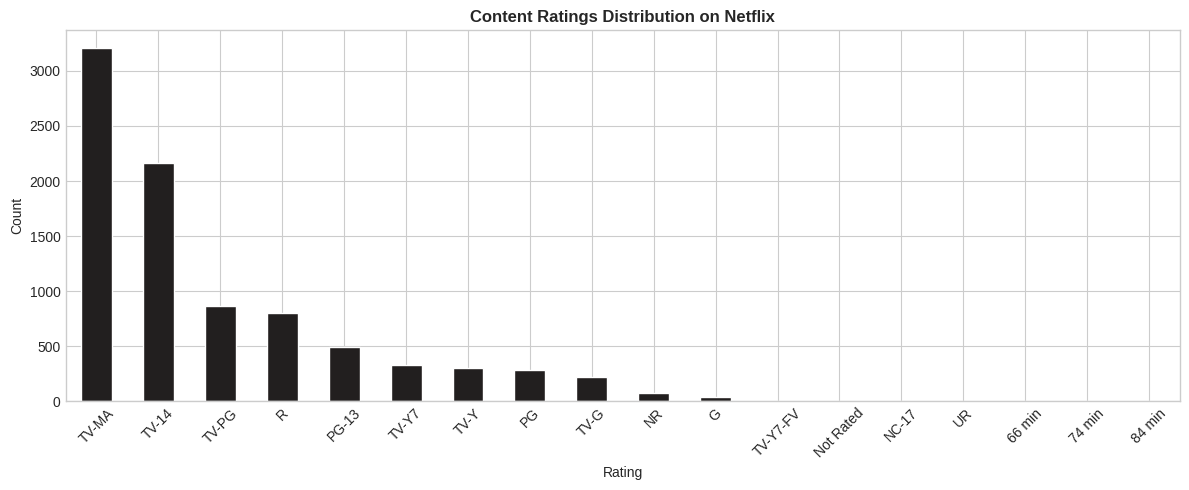

📊 ratings.png saved!


In [14]:
#Ratings Distribution
plt.figure(figsize=(12, 5))
df['rating'].value_counts().plot(
    kind='bar', color='#221F1F', edgecolor='white')
plt.title('Content Ratings Distribution on Netflix', fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 ratings.png saved!")

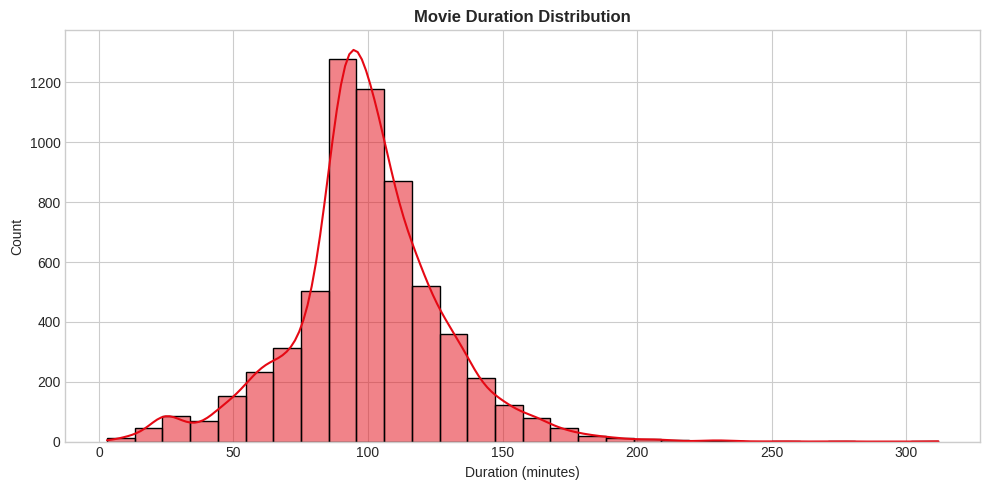

📊 movie_duration.png saved!


In [15]:
#Movie Duration Distribution (Bonus)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration_mins'] = pd.to_numeric(movies['duration_mins'], errors='coerce')

plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_mins'].dropna(), bins=30, color='#E50914', kde=True)
plt.title('Movie Duration Distribution', fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movie_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 movie_duration.png saved!")

In [16]:
from google.colab import files

files.download('movies_vs_shows.png')
files.download('content_per_year.png')
files.download('top_countries.png')
files.download('top_genres.png')
files.download('ratings.png')
files.download('movie_duration.png')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
